# 1. Import Libraries

In [2]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import numpy as np



# 2. Load Dataset and Calculate Quantity

In [3]:
df = pd.read_csv("onlineretail.csv")
Total= df["Quantity"] * df["UnitPrice"]


In [4]:
print(Total)

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Length: 541909, dtype: float64


In [5]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [6]:
df.tail(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,12/9/2011 12:31,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,12/9/2011 12:49,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,12/9/2011 12:49,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,12/9/2011 12:49,8.95,13113.0,United Kingdom
541893,581586,20685,DOORMAT RED RETROSPOT,10,12/9/2011 12:49,7.08,13113.0,United Kingdom
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12,12/9/2011 12:50,1.95,12680.0,France
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,12/9/2011 12:50,1.65,12680.0,France
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12,12/9/2011 12:50,1.65,12680.0,France
541897,581587,22728,ALARM CLOCK BAKELIKE PINK,4,12/9/2011 12:50,3.75,12680.0,France
541898,581587,22727,ALARM CLOCK BAKELIKE RED,4,12/9/2011 12:50,3.75,12680.0,France


# 3. Data Cleaning

In [7]:
#Removed rows with missing CustomerID values and converted CustomerID to integer for matrix building.
df = df.dropna(subset=['CustomerID'])

In [8]:
df['CustomerID'] = df['CustomerID'].astype('int')

In [9]:
df['CustomerID'].dtype


dtype('int32')

# 4. Exploratory Data Analysis (EDA) & Visualizations

**4.1 Top 10 Selling Products**

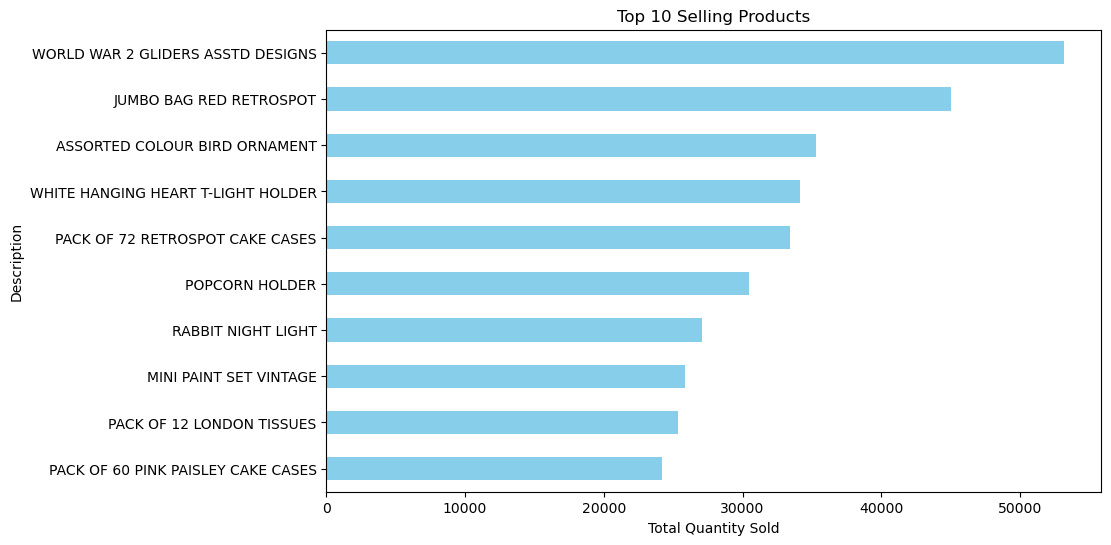

In [10]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(10,6), color='skyblue')
plt.title("Top 10 Selling Products")
plt.xlabel("Total Quantity Sold")
plt.gca().invert_yaxis()
plt.show()


**4.2 Top 10 Customers by Quantity**

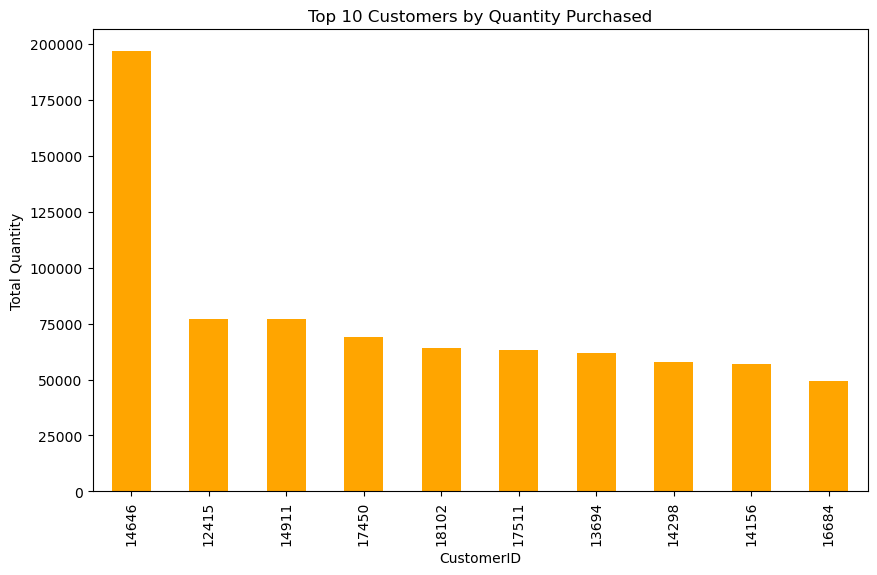

In [11]:
top_customers = df.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='bar', figsize=(10,6), color='orange')
plt.title("Top 10 Customers by Quantity Purchased")
plt.ylabel("Total Quantity")
plt.show()


**4.3 Orders per Country**

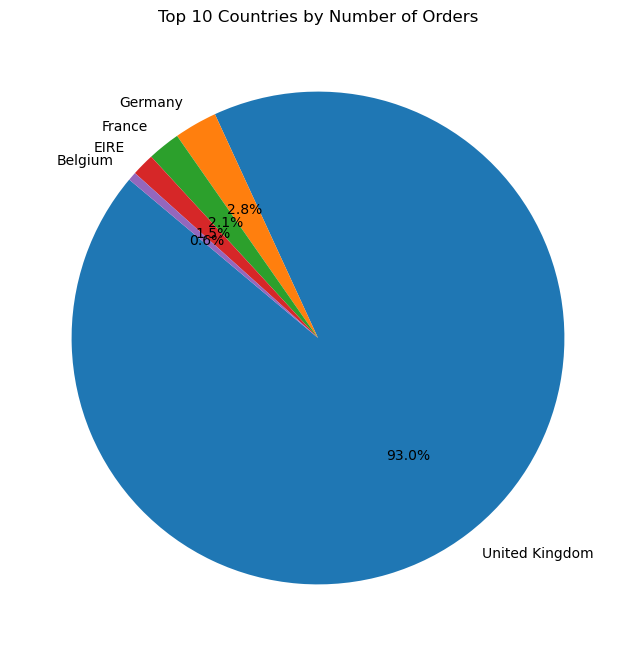

In [12]:
country_orders = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(5)
country_orders.plot(kind='pie', figsize=(8,8), autopct='%1.1f%%', startangle=140)
plt.title("Top 10 Countries by Number of Orders")
plt.ylabel("")
plt.show()


**4.4 Quantity vs Unit Price**

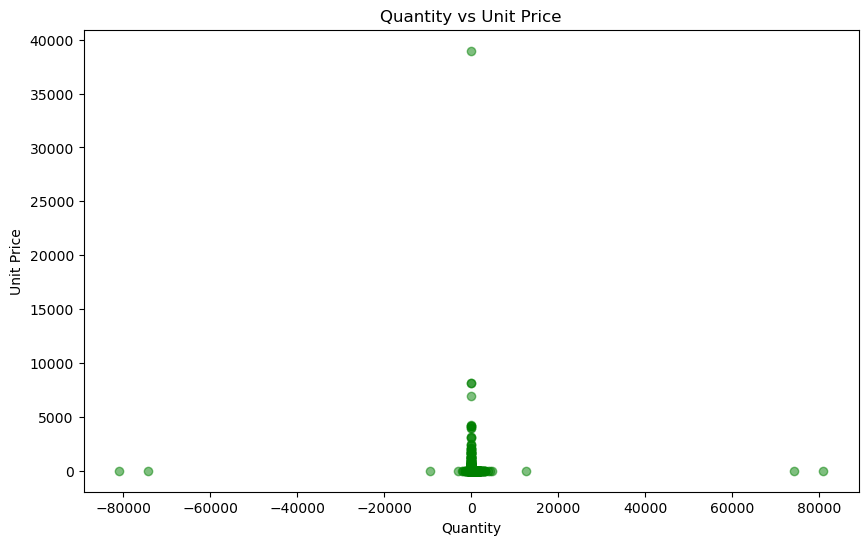

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(df['Quantity'], df['UnitPrice'], alpha=0.5, color='green')
plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()


# 5. Collaborative Filtering (User-Based)

**5.1 Create User-Item Matrix**

In [14]:
#Created a user-item interaction matrix where rows represent customers and columns represent products, using purchase quantity.
user_item_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum'
).fillna(0)

user_item_matrix.shape


(4372, 3885)

**5.2 Convert to Sparse Matrix & Compute Cosine Similarity**

In [15]:
#Converted matrix to sparse format for efficient computation and calculated 
#cosine similarity between customers to identify behavior similarity.
user_item_sparse = csr_matrix(user_item_matrix.values)

user_similarity = cosine_similarity(user_item_sparse)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)


**5.3 Collaborative Filtering Recommendation Function**

In [16]:
#Built a user-based collaborative filtering system that recommends products liked by similar customers, 
#excluding items already purchased
def recommend_products(customer_id, num_recommendations=10):
    if customer_id not in user_item_matrix.index:
        return "Customer ID not found"
    
    similar_customers = user_similarity_df[customer_id].sort_values(ascending=False)[1:11].index
    
    similar_customers_data = user_item_matrix.loc[similar_customers]
    recommendations = similar_customers_data.sum().sort_values(ascending=False)
    
    customer_items = user_item_matrix.loc[customer_id]
    recommendations = recommendations[customer_items == 0]
    
    return recommendations.head(num_recommendations)


**5.4 Test the Recommendation Model**

In [17]:
#Generated top recommended products for Customer 17850 based on customer similarity.
recommend_products(17850)


Description
RED HANGING HEART T-LIGHT HOLDER     164.0
IVORY HANGING DECORATION  HEART       94.0
ORANGE SCENTED SET/9 T-LIGHTS         72.0
ASSORTED COLOUR BIRD ORNAMENT         64.0
T-LIGHT HOLDER SWEETHEART HANGING     56.0
PAINTED METAL PEARS ASSORTED          56.0
WORLD WAR 2 GLIDERS ASSTD DESIGNS     48.0
HOME BUILDING BLOCK WORD              48.0
HANGING CLEAR MINI BOTTLE             48.0
DECORATIVE WICKER HEART SMALL         48.0
dtype: float64

# 6. Content-Based Filtering (Item-Based)

**6.1 Prepare Product Data**

In [18]:
#Created a product dataset for content-based recommendations.
products = df[['StockCode', 'Description']].drop_duplicates()


**6.2 TF-IDF Vectorization**

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import numpy as np

In [20]:
#Vectorized product descriptions and calculated item-item similarity using TF-IDF.
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(products['Description'])
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)


**6.3 Content-Based Recommendation Function**

In [21]:
#Item-based recommendation function to suggest products with similar descriptions.
indices = pd.Series(products.index, index=products['Description']).drop_duplicates()

def recommend_similar_items(description, num_items=10):
    if description not in indices:
        return "Product not found"
    
    idx = indices[description]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:num_items+1]
    product_indices = [i[0] for i in sim_scores]
    
    return products['Description'].iloc[product_indices]


**6.4 Test Content-Based Filtering**

In [22]:
#Successfully retrieved top similar products based on item descriptions.
recommend_similar_items("WHITE HANGING HEART T-LIGHT HOLDER")


396548     PINK HANGING HEART T-LIGHT HOLDER
83          RED HANGING HEART T-LIGHT HOLDER
537621    CREAM HANGING HEART T-LIGHT HOLDER
217        HANGING HEART ZINC T-LIGHT HOLDER
816                     HEART T-LIGHT HOLDER
18143                   HEART T-LIGHT HOLDER
8523        HANGING HEART JAR T-LIGHT HOLDER
453            SILVER HANGING T-LIGHT HOLDER
3611              GLASS HEART T-LIGHT HOLDER
373393     HANGING  BUTTERFLY T-LIGHT HOLDER
Name: Description, dtype: object

# Hybrid Recommendation System

**Step 1: Build TF-IDF Similarity Matrix**

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

df['Description'] = df['Description'].fillna('')

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['Description'])

knn = NearestNeighbors(n_neighbors=10, metric='cosine')
knn.fit(tfidf_matrix)


NearestNeighbors(metric='cosine', n_neighbors=10)